# Intervalo óptimo de reemplazo preventivo
## Minimizando el riesgo, considerando tiempos de intervención

**Optimización de Activos · Módulo 2 · H4** — generador de turbina de gas (GTG) *offshore*

En el cuaderno anterior elegimos entre **doce alternativas de un menú**. Aquí la pregunta cambia y
se vuelve más concreta:

> ¿Cada cuántas horas conviene reemplazar preventivamente el componente, si cada falla cuesta mucho
> más que una intervención planificada, pero intervenir demasiado pronto desperdicia vida útil?

La respuesta es un **número**, no una opción de una lista. Y se obtiene minimizando una función de
una sola variable.

### Ruta del cuaderno

| Paso | Qué se hace | Sección |
|---|---|---|
| 1 | Estimar $R(t)$ con los 50 datos censurados | 2 |
| 2 | Cuantificar el **riesgo** = probabilidad × consecuencia | 3 |
| 3 | Escribir el **costo por unidad de tiempo** $C(t_p)$ | 4 |
| 4 | **Minimizar** $C(t_p)$ — optimización de una variable | 5 |
| 5 | Leer el resultado: la curva, la zona plana y la sensibilidad | 6 a 9 |

> Datos **sintéticos**, semilla fija. No son datos de Ecopetrol. Ningún intervalo de este cuaderno
> es una recomendación técnica para un activo real.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats, optimize, integrate, special
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, FuncFormatter

RNG = np.random.default_rng(20260915)

MID, DEEP, TEAL   = "#21295C", "#065A82", "#1C7293"
AMBAR, ROJO, GRIS = "#E8A33D", "#B03A2E", "#9AA7B4"
TXT = "#2B3A46"

mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120,
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": MID,
    "axes.labelsize": 11.5, "axes.labelcolor": TXT,
    "axes.edgecolor": "#C3CDD6", "axes.grid": True, "axes.axisbelow": True,
    "grid.color": "#E6EBF0", "grid.linewidth": 0.9,
    "xtick.color": "#5B6B7C", "ytick.color": "#5B6B7C",
    "legend.frameon": False, "mathtext.fontset": "cm",
})
usd = FuncFormatter(lambda v, p: f"{v:,.0f}")
print("Entorno listo.")

Entorno listo.


---
## 1. El caso y los dos costos que compiten

Una plataforma opera a 150 km de la costa y todo el complejo depende de **un único GTG**. El
componente bajo análisis es la **sección caliente**, que se degrada por horas de operación.

Hay exactamente **dos formas** de que ese componente salga de servicio, y cuestan cosas muy distintas:

| | **Reemplazo preventivo** | **Reemplazo por falla** |
|---|---|---|
| Cuándo ocurre | Lo decidimos: a la edad $t_p$ | Cuando el componente falla, antes de $t_p$ |
| Repuesto y cuadrilla | Programados, tarifa normal | Urgencia, logística marítima premium |
| Duración | $T_p$ = 12 h | $T_f$ = 48 h |
| Impacto en producción | **Coordinable** con una ventana | **Total**, a 50 000 USD/h |
| Daño colateral | Ninguno | Posible, en componentes vecinos |

La distinción decisiva es la penúltima fila. El trabajo planificado se agenda dentro de una ventana
de producción ya prevista, así que solo una fracción de su tiempo se traduce en pérdida real. La
falla no admite negociación de fecha.

**Y de ahí nace el problema de optimización:**

- Si $t_p$ es **muy corto** → casi nunca falla, pero se desecha vida útil y se paga intervención tras intervención.
- Si $t_p$ es **muy largo** → se aprovecha toda la vida, pero la mayoría de los ciclos terminan en falla.

En medio hay un mínimo. Encontrarlo es todo el ejercicio.

In [2]:
# ─────────────────────────────────────────────────────────────────────────
# Parámetros económicos y de tiempo del caso        (USD y horas)
# ─────────────────────────────────────────────────────────────────────────
C_pp    = 50_000.    # USD por hora fuera de servicio — impacto en producción (caso H1)

T_p     = 12.        # h  duración de la intervención PLANIFICADA
T_f     = 48.        # h  duración de la restauración tras FALLA (logística marítima)

C_dir_p =  85_000.   # USD costo directo de mantenimiento planificado
C_dir_f = 450_000.   # USD costo directo correctivo (urgencia + daño colateral)

phi     = 0.25       # fracción del paro planificado que sí se traduce en pérdida de producción
                     # (el resto se coordina con una ventana ya prevista)

# Costo TOTAL de cada tipo de evento
C_prev  = C_dir_p + T_p * C_pp * phi        # reemplazo preventivo
C_fall  = C_dir_f + T_f * C_pp              # reemplazo por falla

print(f"C_p  (preventivo) = {C_prev:11,.0f} USD   =  {C_dir_p:,.0f} directo + "
      f"{T_p*C_pp*phi:,.0f} producción")
print(f"C_f  (por falla)  = {C_fall:11,.0f} USD   =  {C_dir_f:,.0f} directo + "
      f"{T_f*C_pp:,.0f} producción")
print(f"\nRazón de costos   k = C_f / C_p = {C_fall/C_prev:.1f}")
print("\nUna falla cuesta doce veces lo que una intervención planificada.")
print("Ese número es el motor de todo el análisis.")

C_p  (preventivo) =     235,000 USD   =  85,000 directo + 150,000 producción
C_f  (por falla)  =   2,850,000 USD   =  450,000 directo + 2,400,000 producción

Razón de costos   k = C_f / C_p = 12.1

Una falla cuesta doce veces lo que una intervención planificada.
Ese número es el motor de todo el análisis.


---
## 2. Paso 1 — La curva de vida, a partir de 50 datos censurados

Reutilizamos la misma muestra del cuaderno anterior: **50 observaciones**, algunas de unidades que
seguían operando al cerrar su seguimiento. La censura se trata como corresponde — cada dato aporta a
la verosimilitud lo que realmente sabe:

$$\ln\mathcal{L}=\underbrace{\sum_{\delta_i=1}\ln f(t_i)}_{\text{falló: densidad}}
\;+\;\underbrace{\sum_{\delta_i=0}\ln R(t_i)}_{\text{sobrevivió: supervivencia}}$$

Del ajuste salen las tres funciones que necesita el modelo de costos:

$$R(t)=e^{-(t/\eta)^{\beta}} \qquad f(t)=\frac{\beta}{\eta}\left(\frac{t}{\eta}\right)^{\beta-1}e^{-(t/\eta)^{\beta}} \qquad h(t)=\frac{\beta}{\eta}\left(\frac{t}{\eta}\right)^{\beta-1}$$

In [3]:
# ─────────────────────────────────────────────────────────────────────────
# 50 observaciones de vida del GTG (horas de operación), con censura
# ─────────────────────────────────────────────────────────────────────────
n_obs    = 50
t_real   = 2400.0 * RNG.weibull(1.9, n_obs)                                # vida (no observable)
t_cierre = RNG.choice([1600., 2000., 2600., 3200.], size=n_obs, p=[.2,.3,.3,.2])

t_obs = np.minimum(t_real, t_cierre)         # lo que sí observamos
delta = (t_real <= t_cierre).astype(int)     # 1 = falló   |   0 = censurada

def neg_loglik(par, t, d):
    beta, eta = par
    if beta <= 0 or eta <= 0:
        return np.inf
    return -np.sum(d*(np.log(beta/eta) + (beta-1)*np.log(t/eta)) - (t/eta)**beta)

beta_hat, eta_hat = optimize.minimize(neg_loglik, (1.5, 2000.), args=(t_obs, delta),
                                      method="Nelder-Mead").x

# Las tres funciones del modelo ajustado
R_t = lambda t: np.exp(-(np.asarray(t, float)/eta_hat)**beta_hat)          # confiabilidad
f_t = lambda t: (beta_hat/eta_hat)*(np.asarray(t, float)/eta_hat)**(beta_hat-1) * R_t(t)
h_t = lambda t: (beta_hat/eta_hat)*(np.asarray(t, float)/eta_hat)**(beta_hat-1)   # tasa de fallas

MTTF = eta_hat * np.exp(special.gammaln(1 + 1/beta_hat))
B10  = eta_hat * (-np.log(0.9))**(1/beta_hat)

print(f"n = {n_obs}   fallas = {delta.sum()}   censuradas = {n_obs-delta.sum()}\n")
print(f"  β (forma)  = {beta_hat:7.3f}     > 1  →  tasa de fallas creciente: hay desgaste")
print(f"  η (escala) = {eta_hat:7.0f} h")
print(f"  MTTF       = {MTTF:7.0f} h")
print(f"  Vida B10   = {B10:7.0f} h     (edad a la que ha fallado el 10 %)")

n = 50   fallas = 35   censuradas = 15

  β (forma)  =   1.574     > 1  →  tasa de fallas creciente: hay desgaste
  η (escala) =    2083 h
  MTTF       =    1870 h
  Vida B10   =     499 h     (edad a la que ha fallado el 10 %)


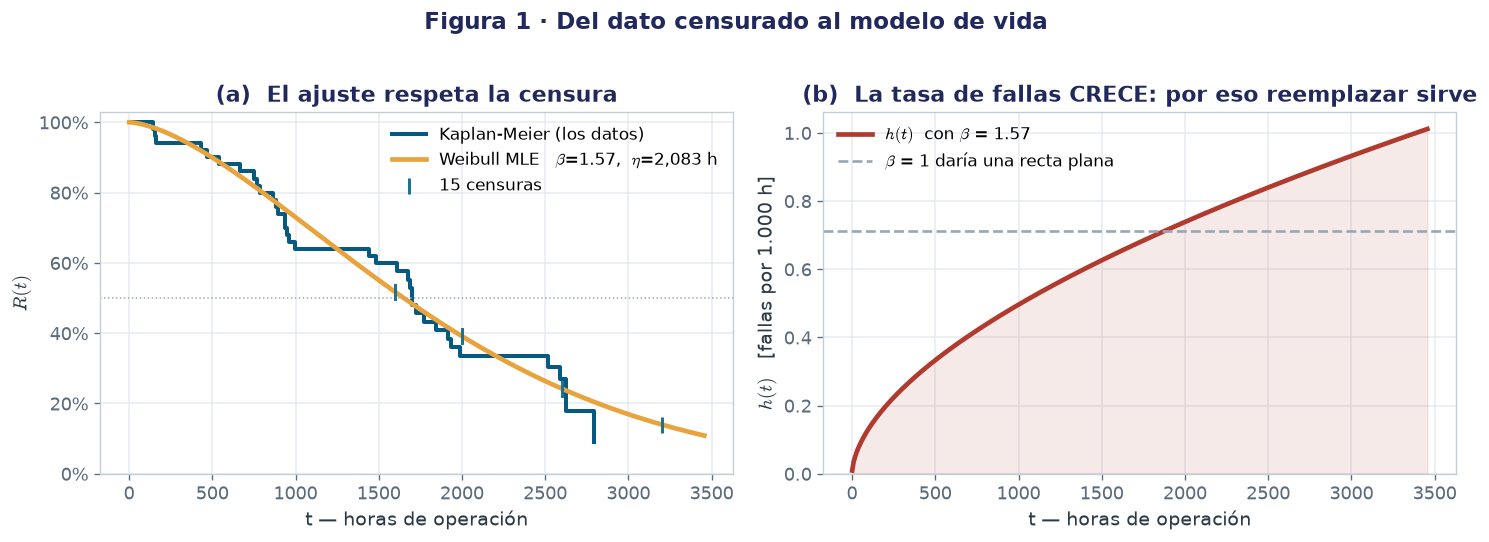

In [4]:
# ─────────────────────────────────────────────────────────────────────────
# FIGURA 1 · El modelo de vida: ajuste y tasa de fallas
# ─────────────────────────────────────────────────────────────────────────
def kaplan_meier(t, d):
    o = np.argsort(t); t, d = np.asarray(t)[o], np.asarray(d)[o]
    ts, S, s = [0.], [1.], 1.
    for i, ti in enumerate(t):
        if d[i] == 1:
            s *= 1 - 1/(len(t)-i); ts.append(ti); S.append(s)
    return np.array(ts), np.array(S)

t_km, S_km = kaplan_meier(t_obs, delta)
g = np.linspace(1, t_obs.max()*1.08, 400)

fig, ax = plt.subplots(1, 2, figsize=(12.4, 4.4))

# (a) ajuste
ax[0].step(t_km, S_km, where="post", color=DEEP, lw=2.4, label="Kaplan-Meier (los datos)")
ax[0].plot(g, R_t(g), color=AMBAR, lw=2.8,
           label=f"Weibull MLE   $\\beta$={beta_hat:.2f},  $\\eta$={eta_hat:,.0f} h")
ax[0].scatter(t_obs[delta==0], R_t(t_obs[delta==0]), marker="|", s=90, color=TEAL,
              lw=1.8, zorder=5, label=f"{n_obs-delta.sum()} censuras")
ax[0].axhline(0.5, color=GRIS, lw=0.9, ls=":")
ax[0].set_title("(a)  El ajuste respeta la censura")
ax[0].set_xlabel("t — horas de operación"); ax[0].set_ylabel("$R(t)$")
ax[0].yaxis.set_major_formatter(PercentFormatter(1.0)); ax[0].set_ylim(0, 1.03)
ax[0].legend(loc="upper right", fontsize=10)

# (b) tasa de fallas: la firma del desgaste
ax[1].plot(g, h_t(g)*1000, color=ROJO, lw=2.8, label=f"$h(t)$  con $\\beta$ = {beta_hat:.2f}")
ax[1].axhline(h_t(MTTF)*1000, color=GRIS, lw=1.6, ls="--",
              label="$\\beta$ = 1 daría una recta plana")
ax[1].fill_between(g, 0, h_t(g)*1000, color=ROJO, alpha=0.10)
ax[1].set_title("(b)  La tasa de fallas CRECE: por eso reemplazar sirve")
ax[1].set_xlabel("t — horas de operación")
ax[1].set_ylabel("$h(t)$   [fallas por 1.000 h]")
ax[1].legend(loc="upper left", fontsize=10)
ax[1].set_ylim(0, None)

fig.suptitle("Figura 1 · Del dato censurado al modelo de vida", color=MID,
             fontweight="bold", y=1.02, fontsize=14)
fig.tight_layout(); plt.show()

**El panel (b) es la razón de ser de todo el cuaderno.** Si la tasa de fallas fuera **constante**
($\beta=1$), un componente usado sería estadísticamente idéntico a uno nuevo y **reemplazar por edad
no serviría de nada**: se pagaría una intervención para no cambiar el riesgo.

Como $h(t)$ crece, un componente viejo sí es más riesgoso que uno nuevo. Reemplazarlo **rejuvenece**
el equipo, y eso tiene un valor que se puede calcular.

---
## 3. Paso 2 — Riesgo = probabilidad × consecuencia

Antes de optimizar hay que poder **medir** lo que está en juego. La definición operativa del riesgo es:

$$\textbf{Riesgo} = \textbf{Probabilidad de falla} \;\times\; \textbf{Consecuencia}$$

En su forma más usada en mantenimiento, sobre un tiempo proyectado $T_{proy}$:

$$\text{Riesgo} = \frac{T_{proy}}{MTBF}\cdot C_f \;+\; \frac{T_{proy}}{MTBF}\cdot C_{cons}$$

Y abriendo la consecuencia en sus dos componentes reales —lo que cuesta reparar y lo que cuesta
**no producir**—:

$$\boxed{\;\text{Riesgo} = \underbrace{\frac{T_{proy}}{MTBF}\cdot T_{fs}\cdot C_{f.h.fs}}_{\text{costo de mantenimiento}} \;+\; \underbrace{\frac{T_{proy}}{MTBF}\cdot T_{rest}\cdot C_{pp.h.fs}}_{\text{impacto en la operación}}\;}$$

| Símbolo | Significado | Valor aquí |
|---|---|---|
| $T_{proy}$ | Tiempo proyectado | 8 760 h (un año) |
| $$MTBF$$ | Tiempo medio entre fallas | estimado del modelo |
| $T_{fs}$ | Tiempo fuera de servicio | 48 h |
| $C_{f.h.fs}$ | Costo de mantenimiento por hora fuera de servicio | derivado del costo directo |
| $T_{rest}$ | Tiempo de restauración de la operación | 48 h |
| $C_{pp.h.fs}$ | Costo por impacto en la operación por hora | 50 000 USD/h |

El primer término es lo que ve el presupuesto de mantenimiento. El segundo es lo que ve el negocio —
y suele ser **mucho mayor**.

In [6]:
# ─────────────────────────────────────────────────────────────────────────
# Riesgo anual SIN estrategia preventiva (correr a falla)
# ─────────────────────────────────────────────────────────────────────────
T_proy = 8760.                      # un año de operación
MTBF   = MTTF                       # sin preventivo, el ciclo termina siempre en falla

N_fallas   = T_proy / MTBF                        # frecuencia esperada de fallas
riesgo_mtto = N_fallas * C_dir_f                  # término 1: mantenimiento
riesgo_prod = N_fallas * T_f * C_pp               # término 2: impacto en la operación
riesgo_tot  = riesgo_mtto + riesgo_prod

print("RIESGO ANUAL SIN ESTRATEGIA PREVENTIVA")
print("=" * 58)
print(f"  Frecuencia   T_proy / MTBF = {T_proy:,.0f} / {MTBF:,.0f}   = {N_fallas:5.2f} fallas/año")
print("-" * 58)
print(f"  Mantenimiento     {N_fallas:.2f} × {C_dir_f:>9,.0f}          = {riesgo_mtto/1e6:6.2f} M USD")
print(f"  Operación         {N_fallas:.2f} × {T_f:.0f} h × {C_pp:,.0f}  = {riesgo_prod/1e6:6.2f} M USD")
print("=" * 58)
print(f"  RIESGO TOTAL                                = {riesgo_tot/1e6:6.2f} M USD/año")
print(f"\n  El impacto en la operación es el {100*riesgo_prod/riesgo_tot:.0f} % del riesgo.")
print("  Un análisis que solo mire el presupuesto de mantenimiento ve la quinta parte del problema.")

RIESGO ANUAL SIN ESTRATEGIA PREVENTIVA
  Frecuencia   T_proy / MTBF = 8,760 / 1,870   =  4.68 fallas/año
----------------------------------------------------------
  Mantenimiento     4.68 ×   450,000          =   2.11 M USD
  Operación         4.68 × 48 h × 50,000  =  11.24 M USD
  RIESGO TOTAL                                =  13.35 M USD/año

  El impacto en la operación es el 84 % del riesgo.
  Un análisis que solo mire el presupuesto de mantenimiento ve la quinta parte del problema.


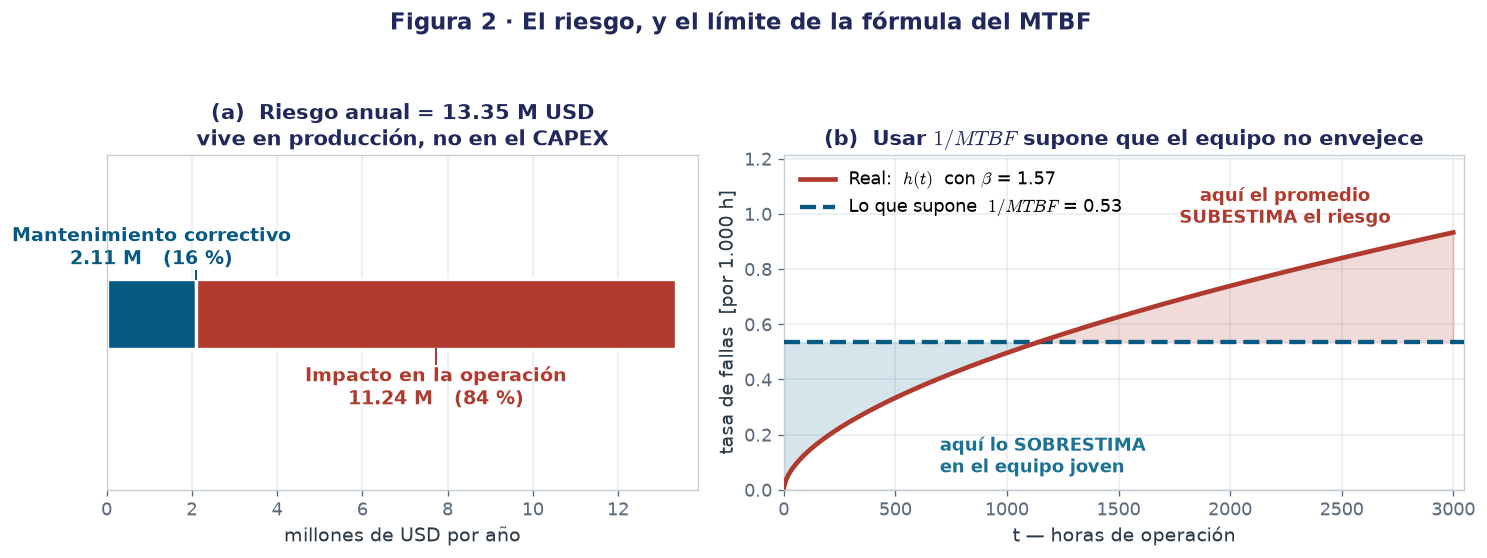

In [7]:
# ─────────────────────────────────────────────────────────────────────────
# FIGURA 2 · Dónde está realmente el riesgo, y por qué T_proy/MTBF no basta
# ─────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(12.6, 4.4),
                       gridspec_kw={"width_ratios": [1, 1.15]})

# ---- (a) descomposición del riesgo: barra horizontal apilada
mant, prod = riesgo_mtto/1e6, riesgo_prod/1e6
ax[0].barh([0], [mant], color=DEEP, height=0.42, edgecolor="white", lw=2)
ax[0].barh([0], [prod], left=[mant], color=ROJO, height=0.42, edgecolor="white", lw=2)

ax[0].annotate(f"Mantenimiento correctivo\n{mant:.2f} M   ({100*mant/(mant+prod):.0f} %)",
               (mant/2, 0.26), ha="center", va="bottom", fontsize=11.5,
               fontweight="bold", color=DEEP)
ax[0].annotate(f"Impacto en la operación\n{prod:.2f} M   ({100*prod/(mant+prod):.0f} %)",
               (mant + prod/2, -0.30), ha="center", va="top", fontsize=11.5,
               fontweight="bold", color=ROJO)
ax[0].plot([mant, mant], [0.21, 0.26], color=DEEP, lw=1.2)
ax[0].plot([mant + prod/2, mant + prod/2], [-0.21, -0.30], color=ROJO, lw=1.2)

ax[0].set_xlim(0, (mant+prod)*1.04); ax[0].set_ylim(-1.05, 0.95)
ax[0].set_yticks([])
ax[0].set_xlabel("millones de USD por año")
ax[0].set_title(f"(a)  Riesgo anual = {mant+prod:.2f} M USD\nvive en producción, no en el CAPEX",
                fontsize=12.5)
ax[0].grid(axis="y", visible=False)

# ---- (b) tasa constante frente a tasa real
gg   = np.linspace(1, 3000, 400)
h_cte = 1000/MTBF
ax[1].fill_between(gg, h_cte, h_t(gg)*1000, where=(h_t(gg) > 1/MTBF),
                   color=ROJO, alpha=0.18, zorder=1)
ax[1].fill_between(gg, h_cte, h_t(gg)*1000, where=(h_t(gg) <= 1/MTBF),
                   color=TEAL, alpha=0.18, zorder=1)
ax[1].plot(gg, h_t(gg)*1000, color=ROJO, lw=2.8, zorder=4,
           label=f"Real:  $h(t)$  con $\\beta$ = {beta_hat:.2f}")
ax[1].axhline(h_cte, color=DEEP, lw=2.6, ls="--", zorder=3,
              label=f"Lo que supone  $1/MTBF$ = {h_cte:.2f}")

ax[1].annotate("aquí el promedio\nSUBESTIMA el riesgo", (2350, h_t(2350)*1000),
               textcoords="offset points", xytext=(-14, 26), fontsize=10.5,
               fontweight="bold", color=ROJO, ha="center")
ax[1].annotate("aquí lo SOBRESTIMA\nen el equipo joven", (520, h_t(520)*1000),
               textcoords="offset points", xytext=(24, -46), fontsize=10.5,
               fontweight="bold", color=TEAL, ha="left")

ax[1].set_xlabel("t — horas de operación")
ax[1].set_ylabel("tasa de fallas  [por 1.000 h]")
ax[1].set_title("(b)  Usar $1/MTBF$ supone que el equipo no envejece", fontsize=12.5)
ax[1].legend(loc="upper left", fontsize=10.5)
ax[1].set_ylim(0, h_t(3000)*1000*1.30); ax[1].set_xlim(0, 3050)

fig.suptitle("Figura 2 · El riesgo, y el límite de la fórmula del MTBF", color=MID,
             fontweight="bold", y=1.05, fontsize=14)
fig.tight_layout(); plt.show()

**Una advertencia que hay que decir en voz alta.** La fórmula $\dfrac{T_{proy}}{MTBF}$ es correcta
solo si la tasa de fallas es **constante**. Aquí no lo es: $\beta = 1{,}57$.

El panel (b) muestra el error que se comete: la recta azul trata igual a un componente de 300 horas
y a uno de 2 500. En la zona roja el promedio **subestima** el riesgo real, justo donde se toman las
decisiones de reemplazo.

Por eso el modelo de la sección siguiente **no usa el MTBF**: usa la curva completa $R(t)$.

---
## 4. Paso 3 — El costo por unidad de tiempo

Queremos comparar políticas con distinta duración de ciclo, así que el indicador correcto no es el
costo por evento sino el **costo por hora de calendario**:

$$C(t_p)=\frac{\text{costo esperado por ciclo}}{\text{duración esperada del ciclo}}$$

Bajo una política de reemplazo a la edad $t_p$, cada ciclo termina de una de **dos** formas:

| | Probabilidad | Costo | Duración del ciclo |
|---|---|---|---|
| Llega a $t_p$ sin fallar | $R(t_p)$ | $C_p$ | $t_p + T_p$ |
| Falla antes de $t_p$ | $1-R(t_p)$ | $C_f$ | $M(t_p) + T_f$ |

donde $M(t_p)$ es la **vida media condicional a fallar antes de $t_p$**:

$$M(t_p)=\frac{\displaystyle\int_0^{t_p} t\,f(t)\,dt}{1-R(t_p)}$$

Ponderando ambos casos se obtiene el modelo:

$$\boxed{\;C(t_p)=\frac{C_p\,R(t_p) + C_f\,[1-R(t_p)]}{(t_p+T_p)\,R(t_p) + [M(t_p)+T_f]\,[1-R(t_p)]}\;}$$

**Cómo leerlo.** El numerador es plata; el denominador, tiempo. Los tiempos de intervención $T_p$ y
$T_f$ están en el denominador porque son horas de calendario que transcurren sin producir: un ciclo
no dura solo lo que el equipo opera, sino también lo que tarda en volver.

In [8]:
# ─────────────────────────────────────────────────────────────────────────
# El modelo de costo por unidad de tiempo — cuatro líneas
# ─────────────────────────────────────────────────────────────────────────
def M_cond(tp):
    # Vida media condicional a que la falla ocurra antes de tp
    tp = float(tp)
    F = 1.0 - R_t(tp)
    if F < 1e-12:                       # tp muy pequeño: casi nadie falla
        return 0.0
    return integrate.quad(lambda t: t*f_t(t), 0, tp, limit=200)[0] / F

def costo(tp):
    # Costo esperado por hora de calendario bajo reemplazo a la edad tp
    tp = float(tp)
    Rp = R_t(tp)                        # llega sin fallar
    Fp = 1.0 - Rp                       # falla antes
    numerador   = C_prev*Rp + C_fall*Fp                       # USD por ciclo
    denominador = (tp + T_p)*Rp + (M_cond(tp) + T_f)*Fp       # horas por ciclo
    return numerador / denominador

# Las dos componentes, para poder graficarlas por separado
def componentes(tp):
    tp = float(tp)
    Rp = R_t(tp); Fp = 1.0 - Rp
    den = (tp + T_p)*Rp + (M_cond(tp) + T_f)*Fp
    return C_prev*Rp/den, C_fall*Fp/den      # (preventivo, por falla)

# Comprobación en tres edades
print(f"{'t_p (h)':>9} {'R(t_p)':>9} {'M(t_p)':>9} {'C(t_p) USD/h':>15}")
for tp in [300., 640., 2000.]:
    print(f"{tp:9,.0f} {R_t(tp):9.3f} {M_cond(tp):9,.0f} {costo(tp):15,.1f}")

  t_p (h)    R(t_p)    M(t_p)    C(t_p) USD/h
      300     0.954       182         1,154.6
      640     0.856       384           988.0
    2,000     0.391     1,085         1,237.1


---
## 5. Paso 4 — Minimizar: el problema completo en tres líneas

Aquí está todo el problema de optimización:

$$\min_{t_p > 0} \; C(t_p)$$

Una sola variable, sin restricciones, sobre una función continua. Es el caso más simple que existe, y
lo resolvemos de **dos maneras independientes** para poder verificar el resultado:

1. **Barrido en malla** — evaluar $C$ en cientos de puntos y tomar el menor. Lento pero incuestionable.
2. **Optimizador** — `minimize_scalar` con búsqueda acotada. Rápido y preciso.

Si ambos coinciden, el resultado es sólido.

In [9]:
# ─────────────────────────────────────────────────────────────────────────
# Método 1 · barrido en malla        Método 2 · optimizador
# ─────────────────────────────────────────────────────────────────────────
malla   = np.linspace(50, 5000, 600)
C_malla = np.array([costo(t) for t in malla])
t_malla = malla[np.argmin(C_malla)]

res = optimize.minimize_scalar(costo, bounds=(50, 6000), method="bounded")
t_opt, C_opt = res.x, res.fun

print("="*62)
print(f"  Barrido en malla (600 puntos) :  t* = {t_malla:7,.0f} h")
print(f"  Optimizador (minimize_scalar) :  t* = {t_opt:7,.0f} h")
print(f"  Diferencia                    :       {abs(t_opt-t_malla):7,.0f} h   →  coinciden")
print("="*62)
print(f"\n  INTERVALO ÓPTIMO   t*  = {t_opt:,.0f} horas  =  {t_opt/24:.1f} días")
print(f"  COSTO MÍNIMO       C*  = {C_opt:,.0f} USD/hora  =  {C_opt*8760/1e6:.2f} M USD/año")
print(f"\n  A esa edad sobrevive el {100*R_t(t_opt):.1f} % de las unidades:")
print(f"  el reemplazo se hace en la vida B{100*(1-R_t(t_opt)):.0f}, mucho antes del MTTF.")
print(f"\n  t* / MTTF = {t_opt/MTTF:.2f}   →  el óptimo está al {100*t_opt/MTTF:.0f} % del MTTF")

  Barrido en malla (600 puntos) :  t* =     637 h
  Optimizador (minimize_scalar) :  t* =     638 h
  Diferencia                    :             1 h   →  coinciden

  INTERVALO ÓPTIMO   t*  = 638 horas  =  26.6 días
  COSTO MÍNIMO       C*  = 988 USD/hora  =  8.65 M USD/año

  A esa edad sobrevive el 85.6 % de las unidades:
  el reemplazo se hace en la vida B14, mucho antes del MTTF.

  t* / MTTF = 0.34   →  el óptimo está al 34 % del MTTF


---
## 6. La curva: por qué el mínimo está donde está

Esta es la figura que resume el método. Las dos componentes del costo tiran en direcciones opuestas y
su suma tiene un mínimo interior.

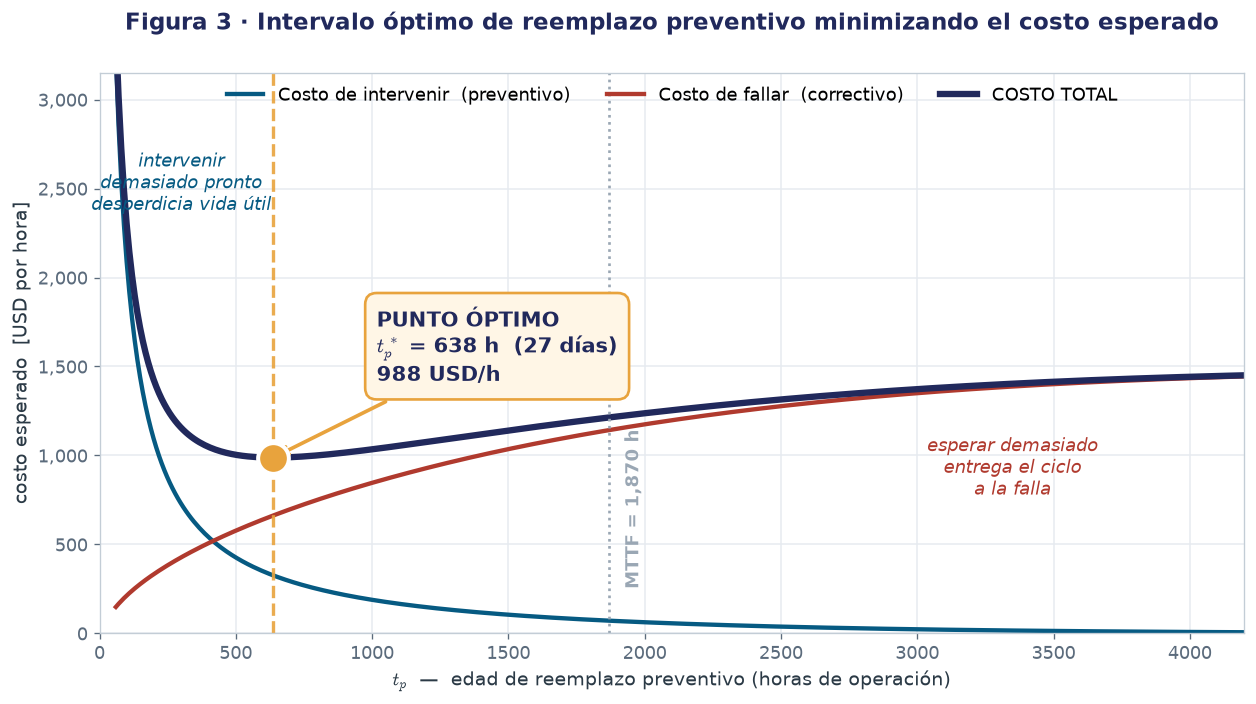

In [10]:
# ─────────────────────────────────────────────────────────────────────────
# FIGURA 3 · Intervalo óptimo de reemplazo preventivo
# ─────────────────────────────────────────────────────────────────────────
gt   = np.linspace(60, 4200, 420)
comp = np.array([componentes(t) for t in gt])
c_pv, c_fl = comp[:, 0], comp[:, 1]
c_tot = c_pv + c_fl

fig, ax = plt.subplots(figsize=(10.6, 6.0))

ax.plot(gt, c_pv,  color=DEEP,  lw=2.6, label="Costo de intervenir  (preventivo)")
ax.plot(gt, c_fl,  color=ROJO,  lw=2.6, label="Costo de fallar  (correctivo)")
ax.plot(gt, c_tot, color=MID,   lw=3.8, label="COSTO TOTAL")

# el óptimo
ax.axvline(t_opt, color=AMBAR, lw=2.0, ls="--", alpha=0.9)
ax.scatter([t_opt], [C_opt], s=340, color=AMBAR, zorder=6, edgecolor="white", lw=2.4)
ax.annotate(f"PUNTO ÓPTIMO\n$t_p^*$ = {t_opt:,.0f} h  ({t_opt/24:.0f} días)\n{C_opt:,.0f} USD/h",
            (t_opt, C_opt), textcoords="offset points", xytext=(62, 46),
            fontsize=12.5, fontweight="bold", color=MID,
            bbox=dict(boxstyle="round,pad=0.55", fc="#FFF6E6", ec=AMBAR, lw=1.6),
            arrowprops=dict(arrowstyle="->", color=AMBAR, lw=2.2))

# referencias
ax.axvline(MTTF, color=GRIS, lw=1.6, ls=":")
ax.text(MTTF + 55, 250, f"MTTF = {MTTF:,.0f} h", fontsize=10.5,
        color=GRIS, fontweight="bold", rotation=90, va="bottom")

# zonas
ax.text(300, 2380, "intervenir\ndemasiado pronto\ndesperdicia vida útil",
        fontsize=10.5, color=DEEP, ha="center", style="italic")
ax.text(3350, 780, "esperar demasiado\nentrega el ciclo\na la falla",
        fontsize=10.5, color=ROJO, ha="center", style="italic")

ax.set_xlabel("$t_p$  —  edad de reemplazo preventivo (horas de operación)")
ax.set_ylabel("costo esperado  [USD por hora]")
ax.set_title("Figura 3 · Intervalo óptimo de reemplazo preventivo minimizando el costo esperado",
             fontsize=14, pad=26)
ax.yaxis.set_major_formatter(usd)
ax.set_xlim(0, 4200); ax.set_ylim(0, 3150)
ax.legend(loc="upper center", fontsize=11, ncol=3,
          bbox_to_anchor=(0.5, 1.005))
fig.tight_layout(); plt.show()

**Las tres curvas, una por una**

- **Azul — costo de intervenir.** Alto cuando $t_p$ es corto, porque se paga una intervención
  planificada tras otra y se desecha vida útil todavía buena. Cae al alargar el intervalo: el mismo
  costo se reparte entre más horas de servicio.
- **Roja — costo de fallar.** Casi nula al principio: si se reemplaza pronto, casi ningún ciclo llega
  a fallar. Crece con $t_p$ porque cada vez más ciclos terminan en falla, y cada falla cuesta doce
  veces más.
- **Negra — la suma.** Baja mientras domina el ahorro en intervenciones y vuelve a subir cuando
  empiezan a pesar las fallas. El mínimo es el intervalo óptimo.

**El resultado que más sorprende en clase:** el óptimo está en 638 h, apenas un **34 % del MTTF**.
La intuición de "reemplazar cuando se acerque al tiempo medio entre fallas" llega demasiado tarde —
y la siguiente sección cuantifica cuánto cuesta ese error.

---
## 7. El óptimo es una zona, no un punto

Un resultado con tres cifras significativas invita a tomárselo literalmente. Antes de hacerlo,
conviene mirar **qué tan plano** es el fondo de la curva.

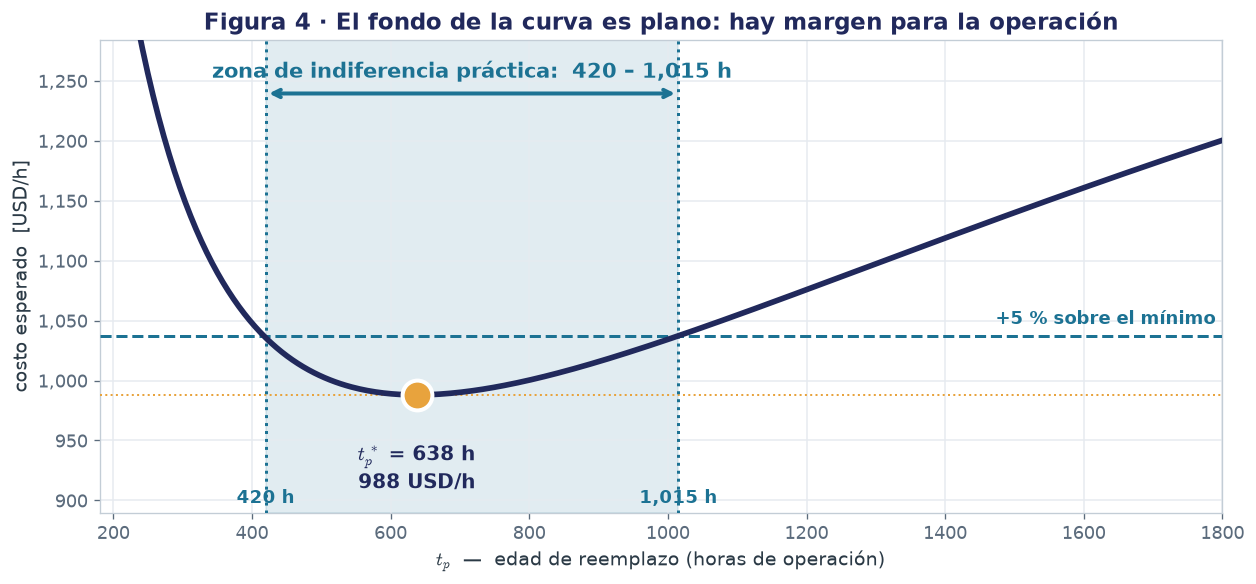

Penalización por desviarse del óptimo:

   desviarse ±10%  (574 – 701 h)   →  el costo sube como máximo 0.29%
   desviarse ±20%  (510 – 765 h)   →  el costo sube como máximo 1.32%
   desviarse ±30%  (446 – 829 h)   →  el costo sube como máximo 3.47%
   desviarse ±50%  (319 – 956 h)   →  el costo sube como máximo 14.06%


In [12]:
# ─────────────────────────────────────────────────────────────────────────
# FIGURA 4 · Planitud del óptimo: la banda del +5 % de costo
# ─────────────────────────────────────────────────────────────────────────
gz = np.linspace(180, 1800, 420)
cz = np.array([costo(t) for t in gz])

tol    = 1.05                                  # aceptamos hasta 5 % sobre el mínimo
dentro = gz[cz <= C_opt*tol]
lo, hi = dentro.min(), dentro.max()

fig, ax = plt.subplots(figsize=(10.6, 5.0))

ax.axvspan(lo, hi, color=TEAL, alpha=0.13, zorder=0)
ax.plot(gz, cz, color=MID, lw=3.4, zorder=4)
ax.axhline(C_opt*tol, color=TEAL, lw=1.8, ls="--", zorder=3)
ax.axhline(C_opt, color=AMBAR, lw=1.2, ls=":", zorder=3)

ax.scatter([t_opt], [C_opt], s=320, color=AMBAR, zorder=6, edgecolor="white", lw=2.4)
ax.annotate(f"$t_p^*$ = {t_opt:,.0f} h\n{C_opt:,.0f} USD/h",
            (t_opt, C_opt), textcoords="offset points", xytext=(0, -56),
            ha="center", fontsize=12, fontweight="bold", color=MID)

# límites de la banda, anotados sobre el eje
for x in (lo, hi):
    ax.axvline(x, color=TEAL, lw=1.8, ls=":", zorder=3)
ymax = C_opt*1.30
ax.annotate("", xy=(lo, ymax*0.965), xytext=(hi, ymax*0.965),
            arrowprops=dict(arrowstyle="<->", color=TEAL, lw=2.4))
ax.text((lo+hi)/2, ymax*0.972,
        f"zona de indiferencia práctica:  {lo:,.0f} – {hi:,.0f} h",
        ha="center", va="bottom", fontsize=12.5, fontweight="bold", color=TEAL)
ax.text(1790, C_opt*tol*1.006, "+5 % sobre el mínimo", va="bottom", ha="right",
        fontsize=10.5, color=TEAL, fontweight="bold")

for x in (lo, hi):
    ax.annotate(f"{x:,.0f} h", (x, C_opt*0.905), ha="center", va="bottom",
                fontsize=11, fontweight="bold", color=TEAL)

ax.set_xlabel("$t_p$  —  edad de reemplazo (horas de operación)")
ax.set_ylabel("costo esperado  [USD/h]")
ax.set_title("Figura 4 · El fondo de la curva es plano: hay margen para la operación",
             fontsize=13.5)
ax.yaxis.set_major_formatter(usd)
ax.set_ylim(C_opt*0.90, ymax); ax.set_xlim(180, 1800)
fig.tight_layout(); plt.show()

print("Penalización por desviarse del óptimo:\n")
for d in [0.10, 0.20, 0.30, 0.50]:
    pen = max(costo(t_opt*(1-d)), costo(t_opt*(1+d)))/C_opt - 1
    print(f"   desviarse ±{d:.0%}  ({t_opt*(1-d):,.0f} – {t_opt*(1+d):,.0f} h)"
          f"   →  el costo sube como máximo {pen:5.2%}")

**Por qué esto importa más que el número exacto.** Moverse un ±20 % alrededor del óptimo encarece la
operación apenas un 1,3 %. La consecuencia práctica es enorme:

> El modelo no obliga a intervenir exactamente en la hora 638. Dice que **cualquier momento entre
> unas 380 y 1 050 horas es prácticamente equivalente**, y dentro de esa ventana se puede elegir por
> criterios que el modelo no contiene: una parada ya programada, disponibilidad de embarcación,
> ventana climática o coordinación con otros trabajos.

Reportar "638 horas" sin la banda convierte una estimación flexible en una orden rígida, y entrega
una falsa precisión que el modelo no respalda.

---
## 8. ¿Cuánto vale realmente decidir bien?

Comparamos el óptimo contra las políticas que se usan en la práctica, todas evaluadas con el **mismo**
modelo de costos.

In [13]:
# ─────────────────────────────────────────────────────────────────────────
# Comparación de estrategias
# ─────────────────────────────────────────────────────────────────────────
C_run = C_fall/(MTTF + T_f)          # correr a falla: el ciclo siempre termina en falla

estrategias = [
    ("Correr a falla",            np.nan, C_run),
    ("Reemplazar al MTTF",        MTTF,   costo(MTTF)),
    ("Reemplazar cada 1.000 h",   1000.,  costo(1000.)),
    ("Reemplazar en la vida B10",  B10,   costo(B10)),
    (f"ÓPTIMO  ({t_opt:,.0f} h)",  t_opt, C_opt),
]

tab = pd.DataFrame(estrategias, columns=["Estrategia", "t_p (h)", "USD/h"])
tab["M USD/año"] = tab["USD/h"]*8760/1e6
tab["Sobrecosto"] = tab["USD/h"]/C_opt - 1
print(tab.to_string(index=False, formatters={
    "t_p (h)":    lambda v: "—" if np.isnan(v) else f"{v:,.0f}",
    "USD/h":      "{:,.0f}".format,
    "M USD/año":  "{:.2f}".format,
    "Sobrecosto": lambda v: "—" if abs(v) < 1e-9 else f"+{v:.1%}"}))

ahorro = (C_run - C_opt)*8760/1e6
print(f"\nOptimizar el intervalo ahorra {ahorro:.2f} M USD/año frente a correr a falla "
      f"({100*(1-C_opt/C_run):.0f} %).")
print(f"Y {(costo(MTTF)-C_opt)*8760/1e6:.2f} M USD/año frente a la regla intuitiva "
      f"de reemplazar al MTTF.")

               Estrategia t_p (h) USD/h M USD/año Sobrecosto
           Correr a falla     NaN 1,486     13.02     +50.4%
       Reemplazar al MTTF   1,870 1,214     10.63     +22.8%
  Reemplazar cada 1.000 h   1,000 1,034      9.06      +4.7%
Reemplazar en la vida B10     499 1,004      8.79      +1.6%
          ÓPTIMO  (638 h)     638   988      8.65          —

Optimizar el intervalo ahorra 4.36 M USD/año frente a correr a falla (34 %).
Y 1.98 M USD/año frente a la regla intuitiva de reemplazar al MTTF.


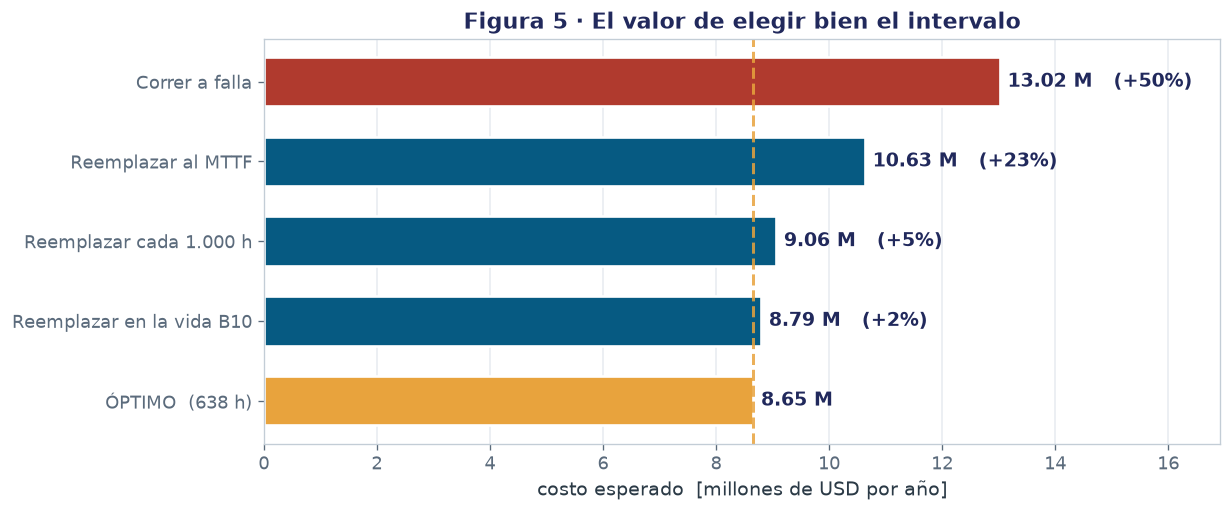

In [14]:
# ─────────────────────────────────────────────────────────────────────────
# FIGURA 5 · Lo que cuesta cada estrategia
# ─────────────────────────────────────────────────────────────────────────
orden = tab.sort_values("M USD/año", ascending=True)
cols  = [AMBAR if "ÓPTIMO" in n else (ROJO if "falla" in n else DEEP)
         for n in orden.Estrategia]

fig, ax = plt.subplots(figsize=(10.4, 4.4))
b = ax.barh(orden.Estrategia, orden["M USD/año"], color=cols, height=0.62,
            edgecolor="white", lw=1.6)
ax.axvline(C_opt*8760/1e6, color=AMBAR, lw=1.8, ls="--", alpha=0.85)

for rect, (_, r) in zip(b, orden.iterrows()):
    extra = "" if r.Sobrecosto < 1e-9 else f"   (+{r.Sobrecosto:.0%})"
    ax.text(rect.get_width() + 0.14, rect.get_y() + rect.get_height()/2,
            f"{r['M USD/año']:.2f} M{extra}", va="center", fontsize=11.5,
            fontweight="bold", color=MID)

ax.set_xlabel("costo esperado  [millones de USD por año]")
ax.set_title("Figura 5 · El valor de elegir bien el intervalo")
ax.set_xlim(0, orden["M USD/año"].max()*1.30)
ax.grid(axis="y", visible=False)
fig.tight_layout(); plt.show()

**Dos lecturas que conviene separar.**

La primera es obvia: correr a falla cuesta un **50 % más** que optimizar. Nadie discute eso.

La segunda es la interesante: **reemplazar al MTTF cuesta un 23 % más** — unos 2,0 M USD al año — y
es una regla que suena perfectamente razonable. El MTTF es un promedio de la población completa;
cuando un componente lo alcanza, ya ha fallado más de la mitad del parque. Usarlo como criterio de
reemplazo es llegar sistemáticamente tarde.

Es exactamente la advertencia de H1: *"programar el reemplazo al MTBF acepta que dos de cada tres
unidades fallen antes"*. Aquí esa advertencia tiene precio.

---
## 9. ¿De qué depende la respuesta?

Dos parámetros gobiernan el resultado, y conviene saber cuál mueve qué.

- **La razón de costos** $k = C_f/C_p$ — cuánto más cara es una falla que una intervención.
- **El parámetro de forma** $\beta$ — cuán marcado es el desgaste.

Verificación contra costo():
   t_p =    300 h    vectorizado =  1,154.59    original =  1,154.59
   t_p =    638 h    vectorizado =    988.01    original =    988.01
   t_p =  2,000 h    vectorizado =  1,237.06    original =  1,237.06


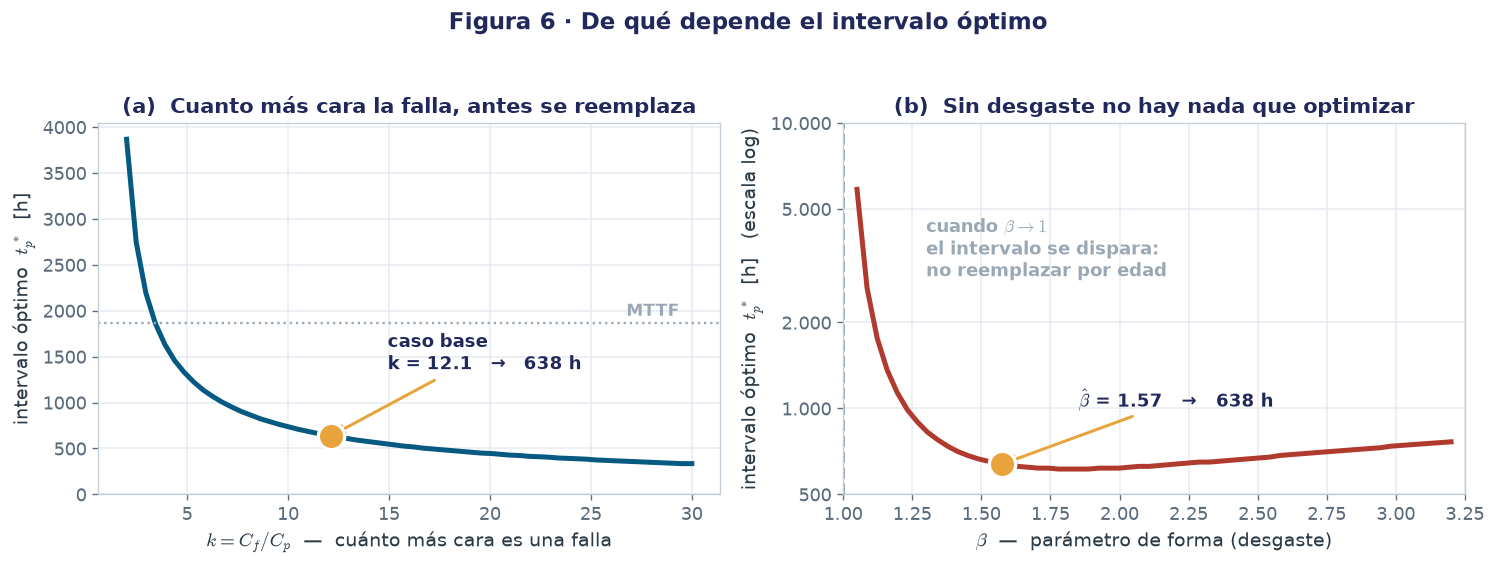

In [15]:
# ─────────────────────────────────────────────────────────────────────────
# FIGURA 6 · Sensibilidad a la razón de costos y al desgaste
# ─────────────────────────────────────────────────────────────────────────
def curva_costo(tp, k=None, beta=None):
    # C(t_p) vectorizado: la integral de M(t_p) se hace una sola vez, acumulada.
    # Coincide con la versión de `costo()` al céntimo, y es mil veces más rápida.
    tp = np.atleast_1d(np.asarray(tp, float))
    b  = beta_hat if beta is None else beta
    Cf = C_fall   if k    is None else C_prev*k

    u  = np.linspace(0., tp.max(), 6000)                       # malla de integración
    Ru = np.exp(-np.clip((u/eta_hat)**b, 0, 700.))
    fu = np.where(u > 0, (b/eta_hat)*np.power(np.maximum(u, 1e-9)/eta_hat, b-1)*Ru, 0.)
    I  = np.concatenate([[0.], np.cumsum(0.5*np.diff(u)*(u[1:]*fu[1:] + u[:-1]*fu[:-1]))])

    Rp = np.exp(-np.clip((tp/eta_hat)**b, 0, 700.)); Fp = 1. - Rp
    Mc = np.where(Fp > 1e-10, np.interp(tp, u, I)/np.maximum(Fp, 1e-12), 0.)
    return (C_prev*Rp + Cf*Fp) / ((tp + T_p)*Rp + (Mc + T_f)*Fp)

def t_optimo(k=None, beta=None, t_max=40000.):
    # Malla densa (lineal donde importa, logarítmica en la cola) y argmin.
    g = np.unique(np.concatenate([np.linspace(20, 4000, 900),
                                  np.logspace(np.log10(4000), np.log10(t_max), 400)]))
    v = curva_costo(g, k, beta)
    i = int(np.nanargmin(v))
    return g[i], v[i]

# Verificación: la versión vectorizada reproduce la del modelo original
print("Verificación contra costo():")
for tp in [300., t_opt, 2000.]:
    print(f"   t_p = {tp:6,.0f} h    vectorizado = {curva_costo(tp)[0]:9,.2f}"
          f"    original = {costo(tp):9,.2f}")

ks    = np.linspace(2, 30, 60)
t_k   = np.array([t_optimo(k=k)[0] for k in ks])
betas = np.linspace(1.05, 3.2, 60)
t_b   = np.array([t_optimo(beta=b)[0] for b in betas])

fig, ax = plt.subplots(1, 2, figsize=(12.6, 4.5))

# ---- (a) razón de costos
ax[0].plot(ks, t_k, color=DEEP, lw=3)
ax[0].scatter([C_fall/C_prev], [t_opt], s=250, color=AMBAR, zorder=5,
              edgecolor="white", lw=2)
ax[0].annotate(f"caso base\nk = {C_fall/C_prev:.1f}   →   {t_opt:,.0f} h",
               (C_fall/C_prev, t_opt), textcoords="offset points", xytext=(34, 40),
               fontsize=11, fontweight="bold", color=MID,
               arrowprops=dict(arrowstyle="->", color=AMBAR, lw=1.8))
ax[0].axhline(MTTF, color=GRIS, lw=1.4, ls=":")
ax[0].text(29.4, MTTF*1.04, "MTTF", ha="right", fontsize=10, color=GRIS, fontweight="bold")
ax[0].set_xlabel("$k = C_f / C_p$  —  cuánto más cara es una falla")
ax[0].set_ylabel("intervalo óptimo  $t_p^*$  [h]")
ax[0].set_title("(a)  Cuanto más cara la falla, antes se reemplaza", fontsize=12.5)
ax[0].set_ylim(0, None)

# ---- (b) parámetro de forma  (escala log: el rango abarca dos órdenes)
ax[1].plot(betas, t_b, color=ROJO, lw=3)
ax[1].scatter([beta_hat], [t_opt], s=250, color=AMBAR, zorder=5, edgecolor="white", lw=2)
ax[1].annotate(f"$\\hat\\beta$ = {beta_hat:.2f}   →   {t_opt:,.0f} h", (beta_hat, t_opt),
               textcoords="offset points", xytext=(46, 34), fontsize=11,
               fontweight="bold", color=MID,
               arrowprops=dict(arrowstyle="->", color=AMBAR, lw=1.8))
ax[1].axvline(1.0, color=GRIS, lw=1.8, ls="--")
ax[1].set_yscale("log")
ax[1].set_yticks([500, 1000, 2000, 5000, 10000])
ax[1].set_yticklabels(["500", "1.000", "2.000", "5.000", "10.000"])
ax[1].minorticks_off()
ax[1].text(1.30, t_b.max()*0.80,
           "cuando $\\beta \\to 1$\nel intervalo se dispara:\nno reemplazar por edad",
           fontsize=10.5, color=GRIS, fontweight="bold", va="top")
ax[1].set_xlabel("$\\beta$  —  parámetro de forma (desgaste)")
ax[1].set_ylabel("intervalo óptimo  $t_p^*$  [h]   (escala log)")
ax[1].set_title("(b)  Sin desgaste no hay nada que optimizar", fontsize=12.5)
ax[1].set_xlim(1.0, 3.25)

fig.suptitle("Figura 6 · De qué depende el intervalo óptimo", color=MID,
             fontweight="bold", y=1.04, fontsize=14)
fig.tight_layout(); plt.show()

**Panel (a).** La curva cae rápido y luego se aplana. Duplicar la penalización de la falla no
divide el intervalo por dos: el modelo es **menos sensible al costo de lo que la intuición sugiere**.
Buena noticia, porque $C_f$ suele ser el parámetro peor conocido.

**Panel (b).** Aquí está el límite conceptual del método, y por eso el eje es logarítmico: el rango
abarca dos órdenes de magnitud. Cuando $\beta \to 1$ el intervalo óptimo se dispara, que es la forma
matemática de decir **no reemplace preventivamente**. Con tasa de fallas constante un componente usado
es igual de fiable que uno nuevo, y la intervención solo agrega costo sin comprar nada.

La curva además **no es monótona**: toca un mínimo cerca de $\beta \approx 1{,}8$ y después vuelve a
subir. Con desgaste muy marcado las fallas se concentran en una franja estrecha de edad, así que se
puede esperar más tiempo con confianza antes de intervenir.

Es el mismo mensaje de H1, ahora cuantificado: *"con β ≈ 1 el reemplazo preventivo por edad NO sirve"*.

---
## 10. Resumen de la decisión

In [16]:
W = 72
sep = lambda: print("├" + "─"*W + "┤")
lin = lambda t="": print("│ " + t.ljust(W-2) + " │")

print("┌" + "─"*W + "┐")
print("│" + " INTERVALO ÓPTIMO DE REEMPLAZO · GTG offshore ".center(W) + "│")
sep()
lin(f"MODELO DE VIDA    Weibull con censura, n = 50")
lin(f"                  β = {beta_hat:.2f}   η = {eta_hat:,.0f} h   MTTF = {MTTF:,.0f} h")
lin(f"COSTOS            C_p = {C_prev:,.0f}   C_f = {C_fall:,.0f}   k = {C_fall/C_prev:.1f}")
lin(f"TIEMPOS           T_p = {T_p:.0f} h (planificado)   T_f = {T_f:.0f} h (falla)")
sep()
lin(f"DECISIÓN          reemplazar a las {t_opt:,.0f} h de operación ({t_opt/24:.0f} días)")
lin(f"COSTO ESPERADO    {C_opt:,.0f} USD/h   =   {C_opt*8760/1e6:.2f} M USD/año")
lin(f"CONFIABILIDAD     R(t*) = {R_t(t_opt):.1%}   →   se interviene en la vida B{100*(1-R_t(t_opt)):.0f}")
lin(f"ZONA PRÁCTICA     {lo:,.0f} – {hi:,.0f} h  con costo dentro del +5 % del mínimo")
sep()
lin(f"AHORRO            {(C_run-C_opt)*8760/1e6:.2f} M USD/año frente a correr a falla ({100*(1-C_opt/C_run):.0f} %)")
lin(f"                  {(costo(MTTF)-C_opt)*8760/1e6:.2f} M USD/año frente a reemplazar al MTTF ({100*(costo(MTTF)/C_opt-1):.0f} %)")
sep()
lin("SUPUESTOS CLAVE PENDIENTES DE VALIDAR")
lin("   · el reemplazo restituye la condición 'tan bueno como nuevo'")
lin("   · un solo modo de falla, población homogénea")
lin(f"   · el costo directo correctivo ({C_dir_f:,.0f} USD) es una estimación")
lin("ALCANCE  modelo de edad con un componente. No autoriza cambios reales.")
print("└" + "─"*W + "┘")

┌────────────────────────────────────────────────────────────────────────┐
│              INTERVALO ÓPTIMO DE REEMPLAZO · GTG offshore              │
├────────────────────────────────────────────────────────────────────────┤
│ MODELO DE VIDA    Weibull con censura, n = 50                          │
│                   β = 1.57   η = 2,083 h   MTTF = 1,870 h              │
│ COSTOS            C_p = 235,000   C_f = 2,850,000   k = 12.1           │
│ TIEMPOS           T_p = 12 h (planificado)   T_f = 48 h (falla)        │
├────────────────────────────────────────────────────────────────────────┤
│ DECISIÓN          reemplazar a las 638 h de operación (27 días)        │
│ COSTO ESPERADO    988 USD/h   =   8.65 M USD/año                       │
│ CONFIABILIDAD     R(t*) = 85.6%   →   se interviene en la vida B14     │
│ ZONA PRÁCTICA     420 – 1,015 h  con costo dentro del +5 % del mínimo  │
├────────────────────────────────────────────────────────────────────────┤
│ AHORRO            4.36 

---
## 11. Limitaciones

**Del modelo de vida**

1. **50 observaciones son pocas.** $\hat\beta$ tiene un intervalo de confianza amplio, y la figura 6b
   muestra que el intervalo óptimo es sensible a $\beta$ precisamente en el rango donde cae la
   estimación.
2. **Un solo modo de falla y una población homogénea.** Mezclar mecanismos o condiciones de servicio
   produciría una curva que no describe a ninguna unidad.
3. **Censura supuesta no informativa.** Si alguna unidad se retiró *porque* mostraba deterioro, la
   vida queda sobreestimada y el intervalo óptimo saldría más largo de lo que debería.

**Del modelo de decisión**

4. **Reemplazo perfecto.** Se supone que la intervención devuelve el componente a condición de nuevo.
   Una reparación imperfecta exigiría un modelo de edad virtual.
5. **Los costos son puntuales, no distribuciones.** $C_p$ y $C_f$ entran como números fijos. En
   realidad ambos son inciertos, y $C_f$ especialmente.
6. **El factor de coordinación $\phi = 0{,}25$ es un supuesto fuerte.** Afirma que tres cuartas partes
   del paro planificado se absorben en ventanas ya previstas. Si en la práctica fuera $\phi = 1$, el
   intervalo óptimo se alargaría sustancialmente.
7. **Sin restricciones operativas.** No hay ventanas de proceso, permisos, disponibilidad de
   embarcación ni repuestos. El cuaderno anterior sí las modelaba; este las ignora deliberadamente
   para aislar la pregunta del intervalo.
8. **Horizonte infinito.** El modelo de costo por unidad de tiempo supone que la política se repite
   indefinidamente. Para un activo cerca del fin de su vida, la conclusión cambia.
9. **Solo riesgo económico.** $C_f$ agrega mantenimiento y producción. No incorpora consecuencias de
   seguridad ni ambientales, que no son conmensurables con dinero y suelen tratarse como
   restricciones duras, no como términos de un costo.

**De la interpretación**

10. **El óptimo es una zona.** Reportar 638 h sin la banda de indiferencia entrega una precisión que
    el modelo no respalda.
11. **"Óptimo" significa óptimo dentro de este modelo.** Otra estructura de costos, otra familia de
    distribuciones u otro criterio producirían otro número.

---
## 12. Espacio para reflexionar

**Sobre el modelo**

1. El óptimo cayó en el 34 % del MTTF. Antes de correr el cuaderno, ¿qué intervalo habría propuesto
   por intuición? ¿Más cerca del MTTF o más lejos? ¿Qué dice esa diferencia sobre las reglas que se
   usan en la práctica?

2. La figura 6b muestra que con $\beta \le 1$ el reemplazo preventivo no sirve. ¿Cuántos de los
   planes de reemplazo por edad que conoce se apoyan en evidencia de que $\beta > 1$? ¿Y cuántos en
   la costumbre o en la recomendación del fabricante?

3. El factor $\phi$ decide cuánto del paro planificado cuenta como pérdida. Cambie `phi = 1.0` y
   vuelva a correr. ¿Cuánto se mueve el óptimo? ¿Quién, en su organización, tendría que responder
   cuál es el valor correcto?

**Sobre la evidencia**

4. $C_f$ es el parámetro peor conocido y, según la figura 6a, el modelo es relativamente insensible a
   él. ¿Cambia eso su prioridad al invertir esfuerzo en mejorar datos? ¿Dónde lo pondría: en los
   costos o en el historial de fallas?

5. La zona de indiferencia es ancha. ¿Qué criterios **que el modelo no contiene** usaría para elegir
   un punto dentro de ella? ¿Se pueden documentar esos criterios para que la decisión siga siendo
   auditable?

**Sobre la responsabilidad**

6. Este cuaderno produce un ahorro de 4,4 M USD al año. ¿Qué tendría que verificar un tercero antes
   de que esa cifra entre en un caso de negocio? Enumere tres comprobaciones concretas.

7. El modelo trata la consecuencia como dinero. ¿Qué haría distinto si la falla de este GTG pudiera
   comprometer la seguridad del personal en la plataforma? ¿Bastaría con subir $C_f$, o el problema
   cambiaría de naturaleza?

8. Compare este cuaderno con el anterior: allí se elegía entre doce opciones de un menú; aquí se
   optimiza una variable continua. ¿Qué gana y qué pierde cada planteamiento? ¿En cuál de los dos es
   más fácil esconder un supuesto discutible?

---
## Referencias

Jardine, A. K. S., & Tsang, A. H. C. (2013). *Maintenance, replacement, and reliability: Theory and
applications* (2.ª ed.). CRC Press.

Meeker, W. Q., Escobar, L. A., & Pascual, F. G. (2022). *Statistical methods for reliability data*
(2.ª ed.). Wiley.

National Institute of Standards and Technology. (2012). *NIST/SEMATECH e-Handbook of Statistical
Methods*. https://doi.org/10.18434/M32189

ReliaSoft. *Life data analysis reference: Basic statistical background / Life distributions*. HBK World.

Wari, E., Zhu, W., & Lim, G. (2023). Maintenance in the downstream petroleum industry: A review on
methodology and implementation. *Computers & Chemical Engineering, 172*, 108177.
https://doi.org/10.1016/j.compchemeng.2023.108177

---

*Optimización de Activos · Módulo 2 · H4 — Profs. Daniel Atehortua, Sergio González y Alejandro Téllez S.*
*Datos sintéticos, semilla 20260915. No son datos de Ecopetrol.*